In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

In [2]:
k_b = 1.3806e-23
Temperature = 1e4 #kelvin

In [4]:
class Electron:
    def __init__(self, position=None, velocity=None, mass=9.11e-31, charge= -1.602e-19):
        
        # Randomly Initialize Position and Velocity
        if position is None:
            position = np.random.uniform(x_min, x_max, size=2)
        if velocity is None:
            velocity = np.random.uniform(0, np.sqrt(k_b * Temperature / mass), size=2)
            
        self.pos = np.array(position, dtype=float)  # Current position vector
        self.vel = np.array(velocity, dtype=float)  # Current velocity vector
        self.mass = mass                             # Mass
        self.charge = charge  # Charge
        self.force = np.zeros(2)    # Force accumulator (reset each frame)
    
    def reset_force(self):
        #reset the Force vector each frame
        self.force[:] = 0.0
    
    def update_velocity(self, delta_t):
       #Updates the veloity based on the current force
        self.vel += self.force / self.mass * delta_t
    
    def update_position(self, delta_t):
        #Updates the position based on the current velocity
        self.pos += self.vel * delta_t

In [5]:
class Proton:
    def __init__(self, position=None, velocity=None, mass=1.67e-27, charge= 1.602e-19):
        
        # If no position/velocity given, initialize randomly
        if position is None:
            position = np.random.uniform(-10, 10, size=2) * Pos_Scale
        if velocity is None:
            velocity = np.random.uniform(np.sqrt(k_b * Temperature / mass), 0, size=2) * Vel_Scale
        
        self.pos = np.array(position, dtype=float)  # Current position vector
        self.vel = np.array(velocity, dtype=float)  # Current velocity vector
        self.mass = mass                             # Mass
        self.charge = charge                         # Charge
        self.force = np.zeros(2) # Force accumulator (reset each frame)
    
    def reset_force(self):
        #reset the Force vector each frame
        self.force[:] = 0.0
    
    def update_velocity(self, delta_t):
        #Updates the veloity based on the current force
        self.vel += self.force / self.mass * delta_t
    
    def update_position(self, delta_t):
        #Updates the position based on the current velocity
        self.pos += self.vel * delta_t

In [7]:
#hard borders so that the particles don't go off to infinity
def apply_walls(particle):
    x, y = particle.pos
    vx, vy = particle.vel

    # X walls
    if x < x_min:
        particle.pos[0] = x_min
        particle.vel[0] = abs(vx)      # reflect right
    elif x > x_max:
        particle.pos[0] = x_max
        particle.vel[0] = -abs(vx)     # reflect left

    # Y walls
    if y < y_min:
        particle.pos[1] = y_min
        particle.vel[1] = abs(vy)      # reflect up
    elif y > y_max:
        particle.pos[1] = y_max
        particle.vel[1] = -abs(vy)     # reflect down

In [14]:
delta_t = 1e-18
substep = 20

k = 8.987e9
N_e = 20
N_p = 10
box_width = 25e-9
box_height = 25e-9

x_max = box_width / 2
x_min = -box_width / 2

y_max = box_height / 2
y_min = -box_height / 2

electrons = [Electron() for _ in range(N_e)]
protons = [Proton() for _ in range(N_p)]

In [15]:
def physics_per_step():
    
    #Reset Forces
    for e in electrons:
        e.reset_force()
    for p in protons:
        p.reset_force()

    # Electron - Proton Attraction
    for e in electrons:
        for p in protons:
            r = e.pos - p.pos
            dist = np.linalg.norm(r) + 1e-12 # additional epsilon to avoid div by zero errors
            e.force += k * p.charge * e.charge * r / dist**3

     # Proton - Electron Attraction
    for p in protons:
        for e in electrons:
            r = p.pos - e.pos
            dist = np.linalg.norm(r) + 1e-12
            p.force += k *  p.charge * e.charge * r / dist**3

    # Electron - Electron Repulsion
    for i, e1 in enumerate(electrons):
        for j, e2 in enumerate(electrons):
            if i != j:
                r = e1.pos - e2.pos
                dist = np.linalg.norm(r) + 1e-12
                e1.force += k * e1.charge * e2.charge * r / dist**3

    # Proton - Proton Repulsion
    for i, p1 in enumerate(protons):
        for j, p2 in enumerate(protons):
            if i != j:
                r = p1.pos - p2.pos
                dist = np.linalg.norm(r) + 1e-12
                p1.force += k * p1.charge * p2.charge * r / dist**3

    for e in electrons:
        e.update_velocity(delta_t)
        e.update_position(delta_t)
        apply_walls(e)

    for p in protons:
        p.update_velocity(delta_t)
        p.update_position(delta_t)
        apply_walls(p)
    
    

In [17]:
def animate(frame):
    for _ in range(substep):
        physics_per_step()

    e_positions = np.array([e.pos for e in electrons], dtype=float).reshape(-1, 2)
    p_positions = np.array([p.pos for p in protons], dtype=float).reshape(-1, 2)
    
    scat_e.set_offsets(e_positions)
    scat_p.set_offsets(p_positions)
    return scat_e, scat_p

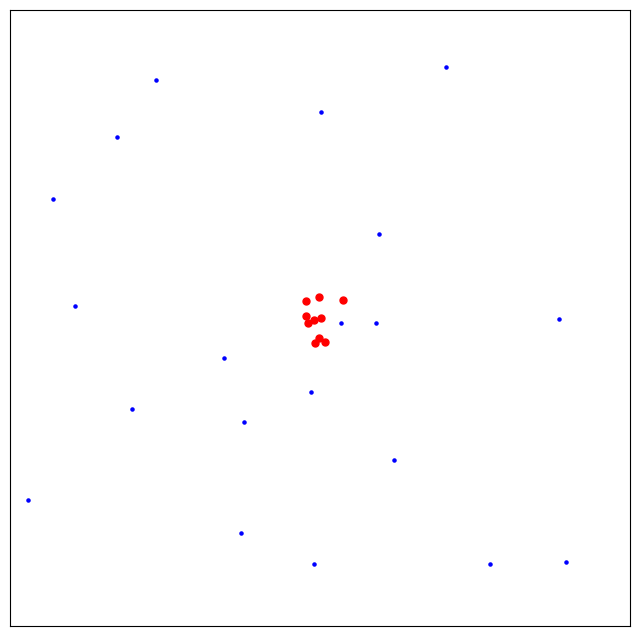

In [18]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_facecolor('w')
ax.get_xaxis().set_ticks([])
ax.get_yaxis().set_ticks([])
scat_e = ax.scatter([], [], s=5, c='blue')  #  electrons
scat_p = ax.scatter([], [], s=25, c='red')   # protons

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=200,
    interval=50,
    blit=True)

ani.save(
    r"C:\Users\ajcoo\Downloads\electrons.gif",
    writer='pillow',
    fps=25
)
